## (*) **WRITE YOUR NAME**, course number and assignment number here
<br>  
<br>


## CSC 380 Homework #1: Maze Search

Your task is to fill in the sections indicated in the code with **"TODO (n)" -- where 1 <= n <= 21**.

Note: the code, as is, does not run.  You can run all parts of 'Part 1' and get outputs (since they are all filled).

But after that, you must at least fill in "TODO (1)" through "(5)", plus "(6)", "(7)", "(8)" for DepthFirst Search (DFS) to check the correctness of your code.

The code is currently using a simple 'maze1'. You can check the output of your code with the html file provided.

THEN **after you confirmed your output was correct**, you change the maze to 'maze2' (in the cell maked under "(*) Part 0-1: Define the maze to use"), and
run your whole code.

Finally, submit both the notebook code file and its pdf output file.

In [ ]:
# -*- coding: utf-8 -*-
"""
CSC 380 Foundations of AI - Search Algorithms Assignment.
Implement DFS, BFS, UCS, Best-First, and A* Search using a generalized framework.
"""
# Import necessary libraries
import heapq
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

## Part 0: Maze Setup

Create two sample mazes and define functions to print and visualize a maze.

In [ ]:
# A maze is a Python list, which is a list of lists.  Each inner list represents
# a row, and elements inside a row represent the columns.  Each element in the
# maze represents a 'cell', and it is referenced by (row_idx, col_idx).
# Possible values for cells are:
#    0 = empty cell, 1 = obstacle, 'S' = start, 'G' = goal

# a simple maze
maze1 = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 'S', 0, 1, 0, 0, 'G'],
    [0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0]
]

# a larger and a bit complex maze
maze2 = [
    ['S', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 'G']
]

In [ ]:
# Print a maze
def print_maze(maze):
    print(f"Maze Layout ({len(maze)}x{len(maze[0])})\n")
    for row in maze:
        print(' '.join(map(str, row)))

In [ ]:
# Visualization function for the maze and final path
def visualize_maze(maze, path=None, explored=None, all_visited_nodes=None, title=None):
    """
    Visualize the maze. Optionally, draw the explored nodes and the final path.
    """
    maze_grid = np.zeros((len(maze), len(maze[0])))
    for i in range(len(maze)):
        for j in range(len(maze[0])):
            if maze[i][j] == 1:
                maze_grid[i][j] = 1  # Wall
            elif maze[i][j] == 'S':
                maze_grid[i][j] = 0.5  # Start
            elif maze[i][j] == 'G':
                maze_grid[i][j] = 0.75  # Goal

    #plt.figure(figsize=(15, 10))
    plt.figure(figsize=(len(maze), len(maze[0])))
    plt.imshow(maze_grid, cmap='hot', interpolation='nearest')
    #plt.colorbar()

    # Mark all visited nodes (lightest blue) - nodes that were ever considered
    if all_visited_nodes:
        all_visited_arr = np.array(list(all_visited_nodes))
        plt.scatter(all_visited_arr[:, 1], all_visited_arr[:, 0],
                   marker='s', color='lightblue', alpha=0.3, s=40, label='Visited')

    # Mark explored nodes (darkest blue) - nodes that were actually expanded
    if explored:
        explored_nodes = np.array(list(explored))
        plt.scatter(explored_nodes[:, 1], explored_nodes[:, 0],
                   marker='X', color='darkblue', alpha=0.7, s=80, label='Explored')

    # Draw the path if provided (green)
    if path:
        path_nodes = np.array(path)
        plt.plot(path_nodes[:, 1], path_nodes[:, 0], marker='o',
                color='green', linewidth=3, markersize=8, label='Path')
        plt.scatter(start_pos[1], start_pos[0], marker='s',
                   color='red', s=150, label='Start')
        plt.scatter(goal_pos[1], goal_pos[0], marker='*',
                   color='yellow', s=200, label='Goal')

    #plt.legend(loc='best')

    # Place legend outside the plot (to the right)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Adjust layout to make room for the legend
    plt.tight_layout()

    if title:
        plt.title(title)
    else:
        plt.title('Search Algorithm Visualization')
    plt.show()

### **(*) Part 0-1: Define the maze to use**

In [ ]:
"""-- Define which maze to use -- """
maze = maze1

In [ ]:
# Show the maze
print_maze(maze)

# Find the start and goal positions
start_pos = None
goal_pos = None
for i, row in enumerate(maze):
    for j, cell in enumerate(row):
        if cell == 'S':
            start_pos = (i, j)
        elif cell == 'G':
            goal_pos = (i, j)

print(f"\nStart: {start_pos}, Goal: {goal_pos}")

# Calculate maze statistics
total_cells = len(maze) * len(maze[0])
blocked_cells = sum(1 for row in maze for cell in row if cell == 1)
free_cells = total_cells - blocked_cells
print(f"Total cells: {total_cells}, Blocked: {blocked_cells}, Free: {free_cells}")

Maze Layout (5x7)

0 0 0 0 0 0 0
0 0 0 1 0 0 0
0 S 0 1 0 0 G
0 0 0 1 0 0 0
0 0 0 0 0 0 0

Start: (2, 1), Goal: (2, 6)
Total cells: 35, Blocked: 3, Free: 32


/tmp/ipython-input-4085430753.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


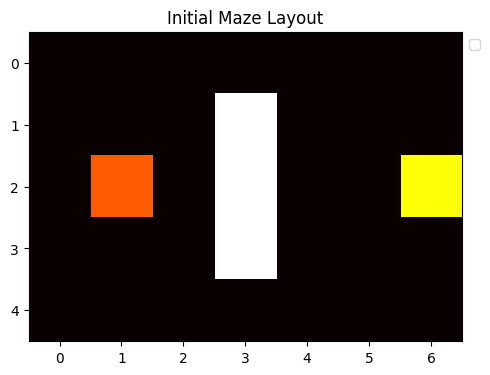

In [ ]:
# Visualize the initial maze
visualize_maze(maze, title='Initial Maze Layout')

## Part 1: **class SearchAlgorithm** -- Abstract base class for various search algorithms

In [ ]:
# Abstract Base Class for Search Algorithms
class SearchAlgorithm(ABC):
    """
    Abstract base class for search algorithms.
    Subclasses (DFS, BFS etc.) must implement the frontier management methods.

    Most importantly, the abstract class includes:
     - self.frontier -- a data structure that holds nodes to be visited/explored

    In addition, the algorithm records nodes during search:
     - explored -- set of all nodes that have been explored/expanded
     - frontier_nodes -- set of all nodes placed in the frontier data structure
     - all_visited_nodes -- set of all nodes ever visited
     - parents -- dictionary, e.g. self.parents[node] -> parent node
     - path_costs -- dictionary, e.g. self._path_costs[node] -> cost
    """

    def __init__(self, maze_layout, start, goal, cost_func=None, heuristic_func=None):
        self.maze = maze_layout
        self.start = start    # start cell, in the form (row_idx, col_idx)
        self.goal = goal      # goal cell, in the form (row_idx, col_idx)
        # cost function (if anything is passed in); g(n)
        self.costfn = cost_func
        # heuristic function (if anything is passed in); h(n)
        self.heuristic = heuristic_func

        ## following variables are used to keep track during search
        self.frontier = None  # will be instanciated with various data structures
        self.max_frontier_size = 0
        self.frontier_nodes = None
        self.explored = None
        self.all_visited_nodes = None
        self.parents = None
        self.path_costs = None # g(n)

    def get_children(self, node):
        """Returns valid child nodes from the current node.
           Note: a node is representd by a cell location (row-idx, col_idx).
        """
        children = []
        n_rows, n_cols = len(self.maze), len(self.maze[0])
        r, c = node

        # neighbor cells, by relative row/col indices from current node
        moves = [(0, 1), (1, 0), (0, -1), (-1, 0)]

        ## TODO (1): Find children of this node that are within the maze,
        ##  also NOT the block (indicated by having a 1 in the cell).
        ##  Add them in 'children' and return it.





    def search(self):
        """The general search algorithm template method."""
        self.explored = set()
        self.frontier_nodes = set()
        self.all_visited_nodes = set()
        self.parents = {}   # dictionary, self.parents[node] -> parent node
        self.path_costs = {self.start: 0} # dictionary, self.path_costs[node] -> cost; g(n)

        # these are abstract methods -- to be concretized in derived search classes
        self._initialize_frontier()
        self.frontier_nodes.add(self.start)
        self.all_visited_nodes.add(self.start)

        # main search loop
        while not self._is_frontier_empty():
            ## TODO (2): Get the next node from frontier.  You can call the
            ##  class method "_get_from_frontier()" to do so.  Set the
            ##  returned node to a variable called 'current_node".



            self.frontier_nodes.discard(current_node) #remove the node from frontier_nodes set

            # (*) Check if the popped node is a goal node.  If so, reconstruct
            # the search path (backward to start) and return values.
            if current_node == self.goal:
                ## TODO (3): Obtain these values and return them (from the function).
                ##  - Reconstructed path from the current node to the start node.
                ##     You can call the class method "_reconstruct_path()" to do so.
                ##  - Path cost of this current node.  It's in self.path_costs dictionary.
                ##  - Three variables, self.explored, self.all_visited_nodes, self.max_frontier_size






            # check if the popped node has been visited before
            if current_node in self.explored:
                # if so, skip the node
                continue

            # add the node to the explored set
            self.explored.add(current_node)

            # for each (valid) child from this node,
            for child in self.get_children(current_node):
                # if the child has not been explored before,
                if child not in self.explored:
                    ## TODO (4): Compute the path cost for the child.
                    ##  If self.costfn is defined, you call the function with the
                    ##   child and obtain the cost of the child.  Then you add the
                    ##   cost to the path cost of the parent/curren node (stored
                    ##   in self.path_costs).  Set the resulting value to a variable
                    ##   'new_cost'.
                    ##  If self.costfn is not defined, you add 1 to the path cost
                    ##   of the parent/curren node (stored in self.path_costs),
                    ##   and set the resulting value to a variable 'new_cost'.






                    # if child's cost has not been computed or the new cost is smaller,
                    if child not in self.path_costs or new_cost < self.path_costs[child]:
                        ## TODO (5): Insert or update the info related to this child.
                        ##  Do the following:
                        ##  - Set the path cost of this child with 'new_cost'
                        ##  - Set the parent of this child with the current node
                        ##  - Add the child, with its new_cost, to frontier.
                        ##      You can do so by calling "_add_to_frontier()".
                        ##  - Add this child in the "all_visited_nodes" set.








        # if goal was not reached, no path is created/returned
        return None, 0, self.explored, self.all_visited_nodes, self.max_frontier_size

    def _reconstruct_path(self, node):
        """Reconstruct the path from start to goal."""
        path = []
        current = node
        while current != self.start:
            path.append(current)
            current = self.parents[current]
        path.append(self.start)
        return path[::-1]

    @abstractmethod
    def _initialize_frontier(self):
        # to be instantiated/implemented by any subclass.
        pass

    @abstractmethod
    def _is_frontier_empty(self):
        # to be instantiated/implemented by any subclass.
        pass

    @abstractmethod
    def _get_from_frontier(self):
        # to be instantiated/implemented by any subclass.
        pass

    @abstractmethod
    def _add_to_frontier(self, node, cost):
        # to be instantiated/implemented by any subclass.
        pass

In [ ]:
def print_search_stats(algo, path, cost, explored, all_visited,  max_fsize):
    print(f"{algo} Path:", path)
    print(f"{algo} Path length:", len(path))
    print(f"{algo} Path cost:", cost)
    print(f"{algo} Max frontier length:", max_fsize)
    print(f"{algo} Explored nodes:", len(explored), "(nodes actually expanded)")
    print(f"{algo} All visited nodes:", len(all_visited), "(nodes ever considered)")

## Part 2: Uninformed Search Algorithms -- DFS, BFS, UCS

DFS Path: [(2, 1), (1, 1), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4), (4, 5), (4, 6), (3, 6), (2, 6)]
DFS Path length: 14
DFS Path cost: 13
DFS Max frontier length: 12
DFS Explored nodes: 20 (nodes actually expanded)
DFS All visited nodes: 30 (nodes ever considered)


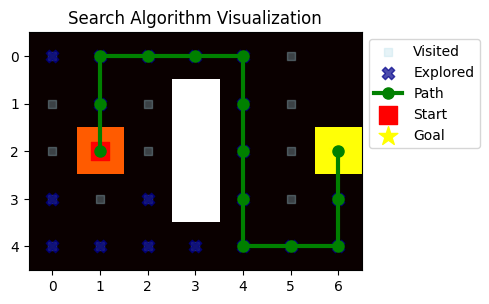

In [ ]:
# 1. Depth-First Search (DFS)
class DFSearch(SearchAlgorithm):
    """
    Depth-First Search implementation using a stack.
    """
    def _initialize_frontier(self):
        ## TODO (6): Initialize frontier with an empty (Python) list and
        ##  add the start node in the list.


    def _is_frontier_empty(self):
        return len(self.frontier) == 0

    def _get_from_frontier(self):
        ## TODO (7): Pop the frontier stack (LIFO) and return the popped node.


    def _add_to_frontier(self, node, cost):
        ## TODO (8): Add to stack/frontier (front of list for LIFO behavior).
        ##  Add just the node (i.e., no cost).
        ##  Also update the max_frontier_size if necessary.





#-----------------------------------------------------------------
# Run DFS
dfs = DFSearch(maze, start_pos, goal_pos)
path, cost, explored, all_visited, max_fsize = dfs.search()

# Print stats and visialize maze
print_search_stats("DFS", path, cost, explored, all_visited, max_fsize)
visualize_maze(maze, path, explored, all_visited)

BFS Path: [(2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (3, 6), (2, 6)]
BFS Path length: 10
BFS Path cost: 9
BFS Max frontier length: 6
BFS Explored nodes: 31 (nodes actually expanded)
BFS All visited nodes: 32 (nodes ever considered)


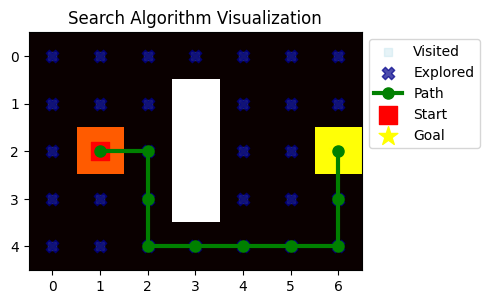

In [ ]:
# 2. Breadth-First Search (BFS)
class BFSearch(SearchAlgorithm):
    """
    Breadth-First Search implementation using a queue.
    Use the Python 'deque' data structure for a FIFO queue:
    https://docs.python.org/3/library/collections.html#collections.deque
    """
    def _initialize_frontier(self):
        # use Python deque to create a frontier list for BFS.
        self.frontier = deque([self.start])

    def _is_frontier_empty(self):
        return len(self.frontier) == 0

    def _get_from_frontier(self):
        ## TODO (9): Dequeue the frontier deque (FIFO) and return the node.
        ##  Use an appropriate function in 'deque' for this task.


    def _add_to_frontier(self, node, cost):
        ## TODO (10): Add the node to the end of the frontier dequeue.
        ##  Add just the node (i.e., no cost).
        ##  Use an appropriate function in 'deque' for this task.
        ##  Also update the max_frontier_size if necessary.





#-----------------------------------------------------------------
# Run BFS
bfs = BFSearch(maze, start_pos, goal_pos)
path, cost, explored, all_visited, max_fsize = bfs.search()

# Print stats and visialize maze
print_search_stats("BFS", path, cost, explored, all_visited, max_fsize)
visualize_maze(maze, path, explored, all_visited)

In [ ]:
## Define a cost function
def cell_cost(node):
    """Arbitrary cost function for cells."""
    r, c = node
    return (r+c)%3 + 1

In [ ]:
# 3. Uniform Cost Search (UCS)
class UCSearch(SearchAlgorithm):
    """
    Uniform Cost Search implementation using a priority queue.
    Uses path cost for prioritization.
    To implement a prioirity queue, use the heapq library:
    https://docs.python.org/3/library/heapq.html

    """
    def _initialize_frontier(self):
        ## TODO (11): Initialize frontier with an empty (Python) list.
        ##  Then create the first entry, which is a tuple (0, self.start),
        ##  representing that the cost of start node is 0.
        ##  Then push the entry in the frontier.
        ##  Use an appropriate function in 'heapq' to do the pushing.
        ##  Doing so makes the frontier work like a priority queue (where cost
        ##  is the value to priorize entries).



    def _is_frontier_empty(self):
        return len(self.frontier) == 0

    def _get_from_frontier(self):
        ## TODO (12): Pop the node with smallest cost and return just the node
        ##  (without cost).
        ##  Use an appropriate function in 'heapq' to do the popping.



    def _add_to_frontier(self, node, cost):
        ## TODO (13): Add the node with the cost (a tuple, i.e., (cost, node))
        ##  in the priority queue frontier.  DO use the parameter 'cost'.
        ##  Use an appropriate function in 'heapq' for this task.
        ##  Also update the max_frontier_size if necessary.





#-----------------------------------------------------------------
# Run UCS
ucs = UCSearch(maze, start_pos, goal_pos, cost_func = cell_cost) # cost function added
path, cost, explored, all_visited, max_fsize = ucs.search()

# Print stats and visialize maze
print_search_stats("UCS", path, cost, explored, all_visited, max_fsize)
visualize_maze(maze, path, explored, all_visited)

<span style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
UCS Path: [(2, 1), (2, 2), (1, 2), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6)]<br>
UCS Path length: 10<br>
UCS Path cost: 18<br>
UCS Max frontier length: 7<br>
UCS Explored nodes: 31 (nodes actually expanded)<br>
UCS All visited nodes: 32 (nodes ever considered)<br>
</span>

![UCS Visualization](img1.png)

## Part 3: Informed Search Algorithms -- Best-First, A-Star

### Part 3-0: Heuristic functions library (with unit tests)
Define three heuristic functions (manhattan_distance, block_through_heuristic and random_heuristic), and test them using a sample maze (with artbitrary current node) as unit-test.

In [ ]:
import random

def manhattan_distance(node, goal, maze=None):
    """Manhattan distance from the current node to the goal node."""
    ## TODO (14): Implement the function.  Remember node and goal are a maze cell,
    ##  a tuple of the form (row_idx, col_idx).  Return the resulting value.





def block_through_heuristic(node, goal, maze):
    """Penalizes paths by the number of blocks that exist between the current
       node and the goal.  Penalty is added to Manhattan distance."""
    wall_penalty = 0

    # find the bounding box defined by node and goal
    r, c = node
    rg, cg = goal

    # Calculate bounding box
    row_start = min(r, rg)
    row_end = max(r, rg)
    col_start = min(c, cg)
    col_end = max(c, cg)

    # count the number of block cells in this box
    count = 0
    for i in range(row_start, row_end+1):
        for j in range(col_start, col_end+1):
            if maze[i][j] == 1:
                count += 1
    # discount the penalty somewhat
    wall_penalty = count * 0.5
    return manhattan_distance(node, goal) + wall_penalty

def random_heuristic(node, goal, maze=None):
    """A random value between (0.5, 2.0) multiplies the Manhattan distance.
       Note that this is a poor heuristic and not admissible..."""
    ## TODO (15): Implement the function.




#--------------------------
# Test heuristics
print("Heuristic values from start to goal:")
for heuristic_func in [manhattan_distance, block_through_heuristic, random_heuristic]:
    value = heuristic_func(start_pos, goal_pos, maze)
    print(f" - {heuristic_func.__name__}: {value:.2f}")

Heuristic values from start to goal:
 - manhattan_distance: 5.00
 - block_through_heuristic: 5.50
 - random_heuristic: 6.24


In [ ]:
# 4. Best-First Search (now with configurable heuristic)
class BestFirstSearch(SearchAlgorithm):
    """
    Best-First Search implementation with a given heuristic function.
    Uses heuristic value only for prioritization.
    """
    def _initialize_frontier(self):
        ## TODO (16): Similar to USSearch, initialize frontier with an empty
        ##  (Python) list. Then call the heuristic function (self.heuristic)
        ##  with the start and goal cells, and the maze (self.maze) and
        ##  obtain the heuristic value between the two cells.
        ##  Then create a tuple (huristic_val, self.start), representing
        ##  the heuristic value of the start node.
        ##  Then push the entry in the frontier.
        ##  Use an appropriate function in 'heapq' to do the pushing.




    def _is_frontier_empty(self):
        return len(self.frontier) == 0

    def _get_from_frontier(self):
        ## TODO (17): Pop the node with smallest heuristic node and return
        ##  just the node (without cost/heuristic value).
        ##  Use an appropriate function in 'heapq' to do the popping.



    def _add_to_frontier(self, node, cost):
        ## TODO (18): First obtain the heuristic value between the node and
        ##  the goal cell.  Then similar to UCSearch, add the node with the
        ##  heuristic value (a tuple, i.e., (heuristic_value, node)) in the
        ##  priority queue frontier.  Ignore the parameter 'cost' -- use the
        ##  heuristic value instead.
        ##  Use an appropriate function in 'heapq' for this task.
        ##  Also update the max_frontier_size if necessary.






#-----------------------------------------------------------------
# Run BestFirst
bf = BestFirstSearch(maze, start_pos, goal_pos, heuristic_func=manhattan_distance)#random_heuristic)#block_through_heuristic)#
path, cost, explored, all_visited, max_fsize = bf.search()

# Print stats and visialize maze
print_search_stats("BestFirst", path, cost, explored, all_visited, max_fsize)
visualize_maze(maze, path, explored, all_visited)

<span style="font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
BestFirst Path: [(2, 1), (2, 2), (1, 2), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6)]<br>
BestFirst Path length: 10<br>
BestFirst Path cost: 9<br>
BestFirst Max frontier length: 8<br>
BestFirst Explored nodes: 10 (nodes actually expanded)<br>
BestFirst All visited nodes: 18 (nodes ever considered)<br>
</span>

![UCS Visualization](img2.png)

A*Search Path: [(2, 1), (2, 2), (1, 2), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6)]
A*Search Path length: 10
A*Search Path cost: 18
A*Search Max frontier length: 7
A*Search Explored nodes: 31 (nodes actually expanded)
A*Search All visited nodes: 32 (nodes ever considered)


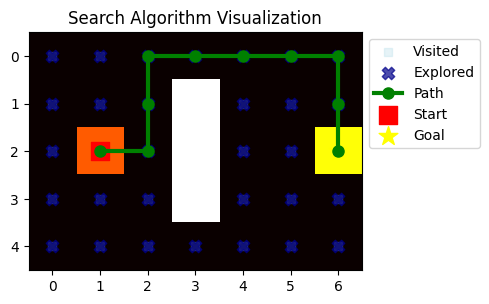

In [ ]:
# 5. A* Search (now with configurable heuristic)
class AStarSearch(SearchAlgorithm):
    """
    A* Search implementation with configurable heuristic.
    Uses f(n) = g(n) + h(n) for prioritization.
    """
    def _initialize_frontier(self):
        ## TODO (19): Similar to BestFirstSearch, initialize frontier with an empty
        ##  (Python) list. Then call the heuristic function (self.heuristic)
        ##  with the start and goal cells, and the maze (self.maze) and
        ##  obtain the heuristic value h(n) between the two cells.
        ##  For g(n), initially set to 0.
        ##  Then create a tuple (h(n)+g(n), self.start), representing
        ##  the combined value of the start node.
        ##  Then push the entry in the frontier.
        ##  Use an appropriate function in 'heapq' to do the pushing.





    def _is_frontier_empty(self):
        return len(self.frontier) == 0

    def _get_from_frontier(self):
        ## TODO (20): Similar to BestFirstSearch,
        ##  Pop the node with the smallest combined value and return
        ##  just the node (without the combined value).
        ##  Use an appropriate function in 'heapq' to do the popping.

    def _add_to_frontier(self, node, cost):
        ## TODO (21): Similar to the _initializaton..() function,
        ##  first obtain the heuristic value (h(n)) between the node and the goal
        ##  cell by calling the heuristic function (self.heuristic) with the
        ##  parameter node and goal cells, and the maze (self.maze).
        ##  For g(n), you obtain by looking up self.path_costs for the node.
        ##  Then add h(n) and g(n) to obtain the combined value.
        ##  obtain the heuristic value h(n) between the two cells.
        ##  Then push the combined score with the node (in a tuple) in the
        ##  priority queue frontier.  Ignore the parameter 'cost' -- use the
        ##  combined value instead.
        ##  Use an appropriate function in 'heapq' for this task.
        ##  Also update the max_frontier_size if necessary.






#-----------------------------------------------------------------
# Run A*
ass = AStarSearch(maze, start_pos, goal_pos, cost_func = cell_cost, heuristic_func=manhattan_distance)#random_heuristic)#block_through_heuristic)#
path, cost, explored, all_visited, max_fsize = ass.search()

# Print stats and visialize maze
print_search_stats("A*Search", path, cost, explored, all_visited, max_fsize)
visualize_maze(maze, path, explored, all_visited)